# Torch Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ExponentialLR, CosineAnnealingLR
import pandas as pd
import pathlib
from collections import namedtuple
from tqdm.auto import tqdm
import collections
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from functools import partial
from sklearn.metrics import roc_auc_score, accuracy_score
import torch.nn.functional as F
from metric import BaseMetrics, MixedMetrics
from data import TabularDataLoader
import math

# My base models

## Linear model

In [3]:
class LinearModel(nn.Module):
    def __init__(self, input_size, output_size, dropout_rate=0):
        super(LinearModel, self).__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.dropout_rate = dropout_rate
        self.linear = nn.Linear(input_size, output_size)
        nn.init.kaiming_normal_(self.linear.weight, mode="fan_in")
        self.dropout = nn.Dropout(self.dropout_rate)

    def freeze(self):
        self.linear.requires_grad_(False)

    def unfreeze(self):
        self.linear.requires_grad_(True)

    def forward(self, x):
        # Apply dropout
        x = self.dropout(x)
        return self.linear(x)

    def predict(self, x):
        return self.linear(x)

In [4]:
class LinearModel(nn.Module):
    def __init__(self, input_size, output_size, dropout_rate=0):
        super(LinearModel, self).__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.dropout_rate = dropout_rate
        self.linear = nn.Linear(input_size, output_size)
        nn.init.kaiming_normal_(self.linear.weight, mode="fan_in")
        self.dropout = nn.Dropout(self.dropout_rate)

    def freeze(self):
        self.linear.requires_grad_(False)

    def unfreeze(self):
        self.linear.requires_grad_(True)

    def forward(self, x):
        # Apply dropout
        x = self.dropout(x)
        return self.linear(x)

    def predict(self, x):
        return self.linear(x)

## Code for continous topk based on Gumbel 

In [5]:
# From https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/DL2/sampling/subsets.html#Subset-Sampler-Class:~:text=%27cuda%27
# Minor modification
EPSILON = np.finfo(np.float32).tiny

class SubsetOperator(torch.nn.Module):
    def __init__(self, k, hard=False):
        super(SubsetOperator, self).__init__()
        self.k = k
        self.hard = hard
        # self.tau = tau

    def forward(self, scores, tau ):
        m = torch.distributions.gumbel.Gumbel(torch.zeros_like(scores), torch.ones_like(scores))
        g = m.sample()
        scores = scores + g

        # continuous top k
        khot = torch.zeros_like(scores)
        onehot_approx = torch.zeros_like(scores)
        for i in range(self.k):
            khot_mask = torch.max(1.0 - onehot_approx, torch.tensor([EPSILON]) )
            scores = scores + torch.log(khot_mask)
            onehot_approx = torch.nn.functional.softmax(scores / tau, dim=1)
            khot = khot + onehot_approx

        if self.hard:
            # straight through
            khot_hard = torch.zeros_like(khot)
            val, ind = torch.topk(khot, self.k, dim=1)
            khot_hard = khot_hard.scatter_(1, ind, 1)
            res = khot_hard - khot.detach() + khot
        else:
            res = khot

        return res

## Masked Linear

In [6]:
class MaskedLinear(nn.Module):
    def __init__(self, input_size, output_size, topK, dropout_rate=0):
        super(MaskedLinear, self).__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.topK = topK
        self.dropout_rate = dropout_rate
        self.linear = nn.Linear(input_size, output_size)
        nn.init.kaiming_normal_(self.linear.weight, mode="fan_in")
        self.dropout = nn.Dropout(self.dropout_rate)

        self.selector = SubsetOperator( k = topK, hard = False)
        
        self.fselector = nn.Buffer(torch.ones((self.input_size,), dtype=torch.float32) )
        
        self.mask = nn.Buffer(torch.ones((self.input_size,), dtype=torch.uint8) )

    def open_gates(self):
        # Create a boolean mask initialized with all elements set to 1 (True)
        self.mask = nn.Buffer(torch.ones((self.input_size,), dtype=torch.uint8) )

    def close_gates(self):
        #print("***Gates closed!")
        weight = self.linear.weight.clone()
        weight = torch.mean(torch.abs(weight), dim=0, keepdim=True)

        # Flatten the weight tensor and calculate the k-th value
        sorted_weights, _ = torch.sort(torch.abs(weight.flatten()), descending=True)
        thr = sorted_weights[self.topK - 1]  # indexes in sorted_weights start from zero...

        # Create a mask based on the threshold
        if self.output_size > 1:
            mask_temp = (torch.abs(weight) >= thr).type(torch.uint8).squeeze()
            self.mask = nn.Buffer(mask_temp)
        else:
            self.mask = nn.Buffer((torch.abs(weight) >=
                                      thr).type(torch.uint8).squeeze() )
            
    def update_fselector(self, tau):
        weight = self.linear.weight.clone()
        weight = torch.mean(torch.abs(weight), dim=0, keepdim=True)
        #self.fselector = nn.Parameter( self.selector(weight, tau), requires_grad = True )
        self.fselector = nn.Buffer( self.selector(weight, tau) )

    def freeze(self):
        self.linear.requires_grad_(False)
        #self.fselector.requires_grad_(False)

    def unfreeze(self):
        self.linear.requires_grad_(True)
        # self.fselector.requires_grad_(True)

    def forward(self, x):
        # Apply mask
        x = self.dropout(x)
        x = x * self.fselector
        x = x * self.mask
        return self.linear(x)

    def predict(self, x):
        x = x * self.mask
        return self.linear(x)

## Loss Function for a MoE model

In [7]:
def BCELossLike_MoE(output, true, weights, class_weights = [1,1]):
    """
    BCE like loss with class weights for a MoE model
    :param output: batchsize x numexperts x 1 - outputs of the experts in the MoE model
    :param true: batchsize x 1 - ground truth
    :param weights: batchsize x numexperts - weights assigned to experts by the gate
    :return:
    """
    batch_size = output.shape[0]
    class_weights_batch = torch.full((batch_size,1), class_weights[0])
    class_weights_batch[true == 1] = class_weights[1]
    #class_weights_batch = class_weights_batch.squeeze()
    true = 2 * true - 1
    #print(f'True {true.shape}')
    output_norm = torch.sigmoid(output * true.unsqueeze(1))
    #print(f'Weights {weights.shape}')
    #print(f'Weights un {weights.unsqueeze(1)}')
    #print(f'Output {output_norm.shape}')
    #loss_batch = - 1/output.shape[1] * torch.log( math.exp(-100.0) + torch.bmm( weights.unsqueeze(1), output_norm ) ) 
    loss_batch = - torch.log( math.exp( - 80.0) + 
                             1/output.shape[1] * torch.bmm( weights.unsqueeze(1), output_norm ) ) 
    loss_batch = loss_batch.squeeze(1) * class_weights_batch #/ (class_weights[0] +class_weights[1])
    #loss_batch = loss_batch * class_weights_batch #/ (class_weights[0] +class_weights[1])
    #print(f'Loss batch {loss_batch}')
    #print(f'Loss batch {loss_batch}')
    loss = torch.mean(loss_batch)
    #print(loss)
    #if torch.isnan(loss):
    #print(f'Output Moe {output_norm}')
    #print(f'Loss batch {loss_batch}')
    #print(f'Class weights {class_weights_batch}')
    #print(f'Total loss {loss}')
        #raise RuntimeError()
    return loss


def Regularization_Loss(model, lambda_l1_exp=0.005, lambda_l1_gate=0.1):
    l1_norm_exp = sum(p.abs().sum() for p in filter(lambda p: p.requires_grad, gmoemodel.experts.parameters()) )
    l1_norm_gate = sum(p.abs().sum() for p in filter(lambda p: p.requires_grad, gmoemodel.gate.parameters()) )
    #l1_norm_exp = sum(p.abs().sum() for p in model.experts.parameters())
    #l1_norm_gate = sum(p.abs().sum() for p in model.gate.parameters())

    return lambda_l1_exp * l1_norm_exp + lambda_l1_gate * l1_norm_gate


LossResult = namedtuple('LossResult', ['loss', 'bce_loss', 'l1_loss'])

class MoELoss(torch.nn.Module):
    def __init__(self, lambda_l1_exp, lambda_l1_gate, #lambda_balancing, 
                 class_weights=[1, 1]):
        super().__init__()
        # self.bce_loss = nn.BCEWithLogitsLoss()
        # self.lambda_balancing = lambda_balancing
        self.lambda_l1_exp = lambda_l1_exp
        self.lambda_l1_gate = lambda_l1_gate
        self.bce = partial(BCELossLike_MoE, class_weights=class_weights)

    def forward(self, outputs, targets, weights, model, validation=False):
        #bce_loss = BCELossLike_MoE(outputs, targets, weights)
        bce_loss = self.bce(outputs, targets, weights)
        #if self.lambda_balancing != 0:
        #    balancing_loss = LoadBalancingLoss(weights, self.lambda_balancing)
        # else:
        #    balancing_loss = torch.tensor([0])
        if (self.lambda_l1_exp !=0 or self.lambda_l1_gate != 0) and (validation == False):
            l1_loss = Regularization_Loss(model, lambda_l1_exp = self.lambda_l1_exp, lambda_l1_gate = self.lambda_l1_gate )
        else: 
            l1_loss = torch.tensor([0])

        loss = bce_loss  + l1_loss

        return LossResult(loss, bce_loss, l1_loss)

# Cosine Annealing for the temperature

In [8]:
def cosine_annealing(epoch, epochs, tau_init, tau_min):
    return tau_min + (tau_init - tau_min) * 0.5 * (math.pow(1 + math.cos( math.pi *(epoch / epochs )) , 1 ) )

# This is our MoE, Gumbel softmax capable version

In [9]:
MoEResult = namedtuple('MoEResult', ['weighted_outputs', 'experts_outputs', 'gate_probs'])
MoEPrediction = namedtuple('MoEPrediction', ['moe_prediction', 'choosen_expert', 'gate_probs', 'experts_prediction'])

class GMoE(nn.Module):
    def __init__(self, input_size, num_experts, type_experts, topk, tau_init, tau_min, gmoe_inference, dropout_rate=0):
        super(GMoE, self).__init__()
        self.num_experts = num_experts
        # self.backmodel = LinearModel(input_size, 1, dropout_rate = 0)
        # self.backmodel.load_state_dict( torch.load('tmp/best_backmodel.pth', weights_only=True) )
        # self.backmodel.requires_grad_(False)

        self.tau_min = tau_min
        self.tau_init = tau_init
        self.gmoe_inference = gmoe_inference
        self.topk = topk

        if type_experts == 'lin' and topk != 0:
            self.experts = nn.ModuleList( MaskedLinear(input_size, 1, topk, dropout_rate) for _ in range(num_experts) )
        elif type_experts == 'lin' and topk == 0:
            self.experts = nn.ModuleList( LinearModel(input_size, 1, dropout_rate) for _ in range(num_experts ) )
        # elif experiment.type_experts == 'mlp':
        #    self.experts = nn.ModuleList( MLP(input_size) for _ in range(num_experts )  )
        # elif experiment.type_experts == 'mlps':
        #   self.experts = nn.ModuleList( MLPS(input_size) for _ in range(num_experts ) )
        # elif experiment.type_experts == 'mlpu':
        #    self.experts = nn.ModuleList( MLPU(input_size) for _ in range(num_experts ) )
        else :
            raise TypeError(f'Adapter type {experiment.type_experts} not implemented')
        #self.adapter.load_state_dict( torch.load('best_backmodel.pth', weights_only=True) )
        
        # self.experts = nn.ModuleList([ self.backmodel]).extend(self.adapter)
        if topk != 0:
            self.gate = MaskedLinear(input_size, num_experts, topk, dropout_rate)
        elif topk == 0:
            self.gate = LinearModel(input_size, num_experts , dropout_rate)

    def open_gates(self):
        if self.topk != 0:
            for expert in range(self.num_experts):
               self.experts[expert].open_gates()
            self.gate.open_gates()
        else:
            pass

    def close_gates(self):
        if self.topk != 0:
            for expert in range(self.num_experts):
               self.experts[expert].close_gates()
            self.gate.close_gates()
        else:
            pass

    def freeze_experts(self):
        for expert in range(self.num_experts):
            self.experts[expert].freeze()

    def unfreeze_experts(self):
        for expert in range(self.num_experts):
            self.experts[expert].unfreeze()

    def update_fselector(self, tau):
        if self.topk != 0:
            for expert in range(self.num_experts):
                self.experts[expert].update_fselector(tau)
            self.gate.update_fselector(tau)
        else:
            pass

    def forward(self, x, tau, alpha_switch):
        
        gate_logits = self.gate(x)
        
        if alpha_switch == 'soft':
            gate_probs = F.softmax(gate_logits , dim=1)
        elif alpha_switch == 'gsoft':
            gate_probs = F.gumbel_softmax(gate_logits, tau = tau, hard=False, dim = 1)
        elif alpha_switch == 'mix':
            alpha = math.pow( (tau - self.tau_min ) / self.tau_init, 0.3 )
            gate_probs = alpha * F.softmax(gate_logits , dim=1) + (1 - alpha) * F.gumbel_softmax(gate_logits, tau = tau, hard=False, dim = 1)
        else:
            raise TypeError(f'{alpha_switch} not implemented')

        #expert_outputs = torch.stack( [ self.backmodel(x),
        #                               self.adapter(x) ], dim=1 )
        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=1)
        weighted_outputs = torch.bmm( gate_probs.unsqueeze(1), expert_outputs ).squeeze(1)

        return MoEResult(weighted_outputs, expert_outputs, gate_probs) 

    def predict(self, x):
        gate_logits = self.gate.predict(x)
        if self.gmoe_inference == 'soft':
            gate_probs = F.softmax(gate_logits, dim=1)
        elif self.gmoe_inference == 'gsoft':
            gate_probs = F.gumbel_softmax(gate_logits, tau = self.tau_min, hard = False, dim = 1)
        else: 
            raise TypeError(f'{self.gmoe_inference} not implemented')
            
        choosen_expert = torch.argmax(gate_probs, dim=1)
        #experts_prediction = torch.stack([F.sigmoid(self.backmodel.predict(x)), 
        #                                  F.sigmoid(self.adapter.predict(x))], 
        #                                 dim=1)
        experts_prediction = torch.stack([F.sigmoid(expert.predict(x)) for expert in self.experts], dim=1)
        result = []
        for record_i, expert_j in enumerate(choosen_expert):
            result.append( F.sigmoid( 
                                     self.experts[expert_j].predict(x[record_i].view(1,-1)).squeeze() ) 
                         )
        return MoEPrediction( torch.stack(result, dim=0), choosen_expert, gate_probs, experts_prediction )

# Hyperparameters setup format

In [10]:
ExperimentSetup = namedtuple('ExperimentSetup', ['datasetpath', 'datasetfile', 'targetcol', 'inputfeatures',
                                                 'batchsize', 'class_weights', 'lambda_l1_exp', 'lambda_l1_gate',
                                                 'num_experts', 
                                                 'type_experts', 'type_fs', 'gate', 'gate_ft',
                                                 'topk',
                                                  'tau_max', 'tau_min', 'optimizer', 'gamma_decay', 'early_stop', 
                                                'gmoe_num_epochs', 'gmoe_inference','gmoe_learning_rate', 'gmoe_learning_rate_gate','gmoe_weightdecay', 
                                                'gmoe_num_epochs_ft', 'gmoe_learning_rate_ft', 'gmoe_weightdecay_ft'
                                                ])

# Log Results

In [11]:
def logresults(df_log, tofile = False, file = 'output.xlsx' ):
    first_columns = df_log[['Dataset', 'Batch size', 'Gate test', 'Gate', 'Gate FT', 
                    'Experts Type', 'Number of Experts', 
                    'Top K', 'LR - gate', 'LR - experts', 'LR - fine tuning', 'Scheduler decay']].loc[0]
    
    columns_to_average = [ 'Accuracy','AUC ROC', 'AUC PRC',  'F1score', 'Precision', 'Sensitivity', 'Specificity', 'Fpr']
    
    average_columns = df_log[columns_to_average].mean(axis=0)
    
    average = pd.concat([first_columns, average_columns], axis=0)
    
    df_average = pd.DataFrame(data = average).T
    
    #df_average 

    df_tofile = df_average
    # Write results to an excel file
    if tofile == True:
        output_file = pathlib.Path(file)
        if output_file.exists():
            df = pd.read_excel(output_file)
            df_tofile = pd.concat([df, df_average], axis=0, join='outer', ignore_index=True)
            
        df_tofile.to_excel(output_file, index=False)

    return df_average

# Random seeds

In [12]:
SEEDS = [42, 53, 64, 75, 86]

# Training of our MoE

In [13]:
# Online training of the MoE model 
def training_phase(experiment, gmoemodel, gmoe_criterion, gmoe_optimizer,  
                   g_scheduler, trainingdata, trainingdata_val, gmoe_list_loss_train, gmoe_list_loss_val, finetuning = False, silent = False):
    gmoe_best_val_loss = float('inf')
    
    tau_init = experiment.tau_max
    tau_min = experiment.tau_min

    if finetuning == False:
        alpha = experiment.gate
        
        if silent == False:
            iterator = tqdm(range(experiment.gmoe_num_epochs));
        else:
            iterator = range(experiment.gmoe_num_epochs) 
    else:
        alpha = experiment.gate_ft
        if silent == False:
            iterator = tqdm(range(experiment.gmoe_num_epochs_ft));
        else:
            iterator = range(experiment.gmoe_num_epochs_ft) 
        
    not_improved_count = 0
    for epoch in iterator:
        gmoemodel.train()
        
        if experiment.type_fs == 'l1' and experiment.topk != 0:
            gmoemodel.open_gates()
        total_loss = 0

        # Aggiornamento della temperatura con Cosine Annealing
        tau = cosine_annealing(epoch , experiment.gmoe_num_epochs, tau_init, tau_min)
    
        my_count = 1
        for x_batch, y_batch in trainingdata:
            gmoe_optimizer.zero_grad()
            
            if experiment.type_fs == 'gsoft' and experiment.topk != 0:
                gmoemodel.update_fselector(tau)
                
            output = gmoemodel.forward(x_batch, tau, alpha_switch = alpha)
            loss = gmoe_criterion.forward(output.experts_outputs , y_batch, output.gate_probs, gmoemodel).loss
            #print(f'Loss ext {loss}')
            if torch.isnan(loss):
                raise RuntimeError()
            loss.backward()
            gmoe_optimizer.step()
            total_loss += loss.item()
        g_scheduler.step()
        avg_train_loss = total_loss / len(trainingdata)
        gmoe_list_loss_train.append(avg_train_loss)
        
        # Validation phase
        gmoemodel.eval()
        total_val_loss = 0
        
        # sepsis4data_val = sepsis4data.split_validation()
        with torch.no_grad():
            if experiment.type_fs == 'gsoft' and experiment.topk != 0:
                gmoemodel.update_fselector(tau)
            elif experiment.type_fs == 'l1' and experiment.topk != 0:
                gmoemodel.close_gates()
                
            for x_batch, y_batch in trainingdata_val:
             #for x_batch, y_batch in testdata:
                val_output = gmoemodel.forward(x_batch, tau, alpha_switch = alpha)
                val_loss = gmoe_criterion.forward(val_output.experts_outputs , y_batch, val_output.gate_probs, gmoemodel).loss
                total_val_loss += val_loss.item()
    
        avg_val_loss = total_val_loss / len(trainingdata_val)
        gmoe_list_loss_val.append(avg_val_loss)
        if avg_val_loss < gmoe_best_val_loss:
            gmoe_best_val_loss = avg_val_loss
            torch.save(gmoemodel.state_dict(), 'tmp/best_'+experiment.datasetfile+'.pth')
            if silent == False:
                print(f'Epoch {epoch}, Train Loss: {avg_train_loss}, Validation Loss: {avg_val_loss} - Saving Best Model')
        else:
            if experiment.early_stop != 0:
                if not_improved_count < experiment.early_stop:
                    not_improved_count += 1 
                else:
                    if silent == False:
                        print(f'Validation performance didn\'t improve for {not_improved_count} epochs.')
                    break
        #else:
        #   print(f'Epoch {epoch}, Train Loss: {avg_train_loss}, Validation Loss: {avg_val_loss} - No Model Update          ')
    return gmoe_list_loss_train, gmoe_list_loss_val

# Test function

In [14]:
def testmodel(gmoemodel, testdata, SEED):
    with torch.no_grad():
        gmoemodel.close_gates()
        gmoeprediction = gmoemodel.predict(torch.tensor(testdata.dataset.x))
    
    gmoechoosenexpert = gmoeprediction.choosen_expert.cpu().numpy()
    percentage_assignment = collections.Counter(np.squeeze(gmoechoosenexpert))
    for k in range(experiment.num_experts):
        if k in percentage_assignment.keys():
            percentage_assignment[k] = round( percentage_assignment[k] / len(gmoechoosenexpert)  * 100, 3)
        else: 
            percentage_assignment[k] = 0
    percentage_assignment = { key: percentage_assignment[key] for key in sorted(percentage_assignment)}
    gmoe_percentage_assignment = list((f'Expert_{key}', value) for (key, value) in percentage_assignment.items())
    gmoe_percentage_assignment
    
    
    gmoemodel_metrics = BaseMetrics(output = gmoeprediction.moe_prediction, target = testdata.dataset.y ) + MixedMetrics(output = gmoeprediction.moe_prediction, target = testdata.dataset.y )
    gmoemodel_metrics_log = [('Dataset', experiment.datasetfile), ('Batch size', experiment.batchsize), ( 'Randomseed', SEED), 
                             ('Gate test', experiment.gmoe_inference),
                             ('Gate', experiment.gate),
                             ('Gate FT', experiment.gate_ft),
                             ('Experts Type', experiment.type_experts),
                             ('Number of Experts', experiment.num_experts),
                             ('Top K', experiment.topk),
                             ('LR - gate', experiment.gmoe_learning_rate_gate),
                             ('LR - experts', experiment.gmoe_learning_rate),
                             ('LR - fine tuning', experiment.gmoe_learning_rate_ft),
                             ('Scheduler decay', experiment.gamma_decay)
                              ] + gmoemodel_metrics + gmoe_percentage_assignment
    gmoemodel_metrics_log
    
    names_experts = [expert[0] for expert in gmoe_percentage_assignment]
    
    # df_vmodel = pd.DataFrame({k: [v] for k, v in vmoemodel_metrics_log})
    df_gmodel = pd.DataFrame({k: [v] for k, v in gmoemodel_metrics_log})
    # df_log = pd.concat([df_vmodel, df_gmodel ], axis=0, join='outer', ignore_index=True)
    #df_log = pd.concat([ df_himodel, df_himodelalt], axis=0, join='outer', ignore_index=True)
    
    my_index = ['Dataset', 'Batch size', 'Randomseed' , 'Gate test', 'Gate', 'Gate FT', 
                'Experts Type', 'Number of Experts', 
                'Top K', 'LR - gate', 'LR - experts', 'LR - fine tuning', 'Scheduler decay', 'Accuracy',
                'AUC ROC', 'AUC PRC', 
                 'F1score', 'Precision', 'Sensitivity', 'Specificity', 'Fpr' ] + names_experts
    df_log = df_gmodel[my_index]
    
    return df_log

# Heartdesease - Diabetes

## Setup and hyperparameters

In [33]:
datadir = './data/medical_data/'

heartdesease = ExperimentSetup(
    datasetpath = datadir + "heart_desease",
    datasetfile = "heart_desease",
    targetcol = "Label",
    inputfeatures = 13,
    batchsize = 16,
    class_weights = [1,1],
    lambda_l1_exp = 0,
    lambda_l1_gate = 0, 
    num_experts = 2,
    type_experts = 'lin',
    type_fs = 'l1',
    gate = 'gsoft',
    gate_ft = 'gsoft',
    topk = 0,
    tau_max = 1,
    tau_min = 0.1,
    optimizer = 'Adam',
    gamma_decay = 1,
    early_stop = 10,
    gmoe_num_epochs = 100,
    gmoe_inference = 'soft',
    gmoe_learning_rate = 0.03,
    gmoe_learning_rate_gate = 0.03,
    gmoe_weightdecay = 0,
    gmoe_num_epochs_ft = 100,
    gmoe_learning_rate_ft = 0.03,
    gmoe_weightdecay_ft = 0
)

diabetesfs = ExperimentSetup(
    datasetpath = datadir + "diabetes",
    datasetfile = "diabetes",
    targetcol = "Label",
    inputfeatures = 21,
    batchsize = 16,
    class_weights = [1,1],
    lambda_l1_exp = 0,
    lambda_l1_gate = 0, 
    num_experts = 2,
    type_experts = 'lin',
    type_fs = 'gsoft',
    gate = 'gsoft',
    gate_ft = 'gsoft',
    topk = 6,
    tau_max = 1,
    tau_min = 0.1,
    optimizer = 'Adam',
    gamma_decay = 1,
    early_stop = 10,
    gmoe_num_epochs = 100,
    gmoe_inference = 'soft',
    gmoe_learning_rate = 0.0005,
    gmoe_learning_rate_gate = 0.0005,
    gmoe_weightdecay = 0,
    gmoe_num_epochs_ft = 100,
    gmoe_learning_rate_ft = 0.0005,
    gmoe_weightdecay_ft = 0
)

diabetes = ExperimentSetup(
    datasetpath = datadir + "diabetes",
    datasetfile = "diabetes",
    targetcol = "Label",
    inputfeatures = 21,
    batchsize = 16,
    class_weights = [1,1],
    lambda_l1_exp = 0,
    lambda_l1_gate = 0, 
    num_experts = 2,
    type_experts = 'lin',
    type_fs = 'gsoft',
    gate = 'gsoft',
    gate_ft = 'gsoft',
    topk = 0,
    tau_max = 1,
    tau_min = 0.1,
    optimizer = 'Adam',
    gamma_decay = 1,
    early_stop = 10,
    gmoe_num_epochs = 100,
    gmoe_inference = 'soft',
    gmoe_learning_rate = 0.001,
    gmoe_learning_rate_gate = 0.001,
    gmoe_weightdecay = 0,
    gmoe_num_epochs_ft = 100,
    gmoe_learning_rate_ft = 0.001,
    gmoe_weightdecay_ft = 0
)

## Set the random seed and Start Training

 
 On line Training 
 


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0, Train Loss: 1.107981213709203, Validation Loss: 1.0501449487426064 - Saving Best Model
Epoch 1, Train Loss: 1.0072298718661796, Validation Loss: 1.0497539910403164 - Saving Best Model
Epoch 2, Train Loss: 0.9889156265956599, Validation Loss: 1.0144577514041553 - Saving Best Model
Epoch 3, Train Loss: 0.9735263295289946, Validation Loss: 1.0022762092677029 - Saving Best Model
Epoch 5, Train Loss: 0.9592596045354518, Validation Loss: 0.9979176683859392 - Saving Best Model
Epoch 9, Train Loss: 0.9408465274950353, Validation Loss: 0.987551521171223 - Saving Best Model
Validation performance didn't improve for 10 epochs.
 
 Fine Tuning 
 


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0, Train Loss: 0.9407278502859721, Validation Loss: 1.0090260397304187 - Saving Best Model
Epoch 3, Train Loss: 0.929052496828684, Validation Loss: 1.0027607029134578 - Saving Best Model
Epoch 4, Train Loss: 0.9236279304434614, Validation Loss: 0.9858128970319574 - Saving Best Model
Epoch 13, Train Loss: 0.9185553876365103, Validation Loss: 0.9825433059172197 - Saving Best Model
Validation performance didn't improve for 10 epochs.
 
 On line Training 
 


...

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0, Train Loss: 1.1427022931052417, Validation Loss: 1.0667290687561035 - Saving Best Model
Epoch 3, Train Loss: 0.980528869280001, Validation Loss: 1.045939179984006 - Saving Best Model
Epoch 4, Train Loss: 0.98191970005268, Validation Loss: 1.027757232839411 - Saving Best Model
Epoch 8, Train Loss: 0.955785771695579, Validation Loss: 1.007942188869823 - Saving Best Model
Epoch 9, Train Loss: 0.9455408119573826, Validation Loss: 1.0058085484938188 - Saving Best Model
Epoch 10, Train Loss: 0.9339786259139456, Validation Loss: 0.9902222915129228 - Saving Best Model
Validation performance didn't improve for 10 epochs.
 
 Fine Tuning 
 


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0, Train Loss: 0.9345814920053249, Validation Loss: 0.9801576245914806 - Saving Best Model
Validation performance didn't improve for 10 epochs.


,Dataset,Batch size,Randomseed,Gate test,Gate,Gate FT,Experts Type,Number of Experts,Top K,LR - gate,LR - experts,LR - fine tuning,Scheduler decay,Accuracy,AUC ROC,AUC PRC,F1score,Precision,Sensitivity,Specificity,Fpr,Expert_0,Expert_1
0,heart_desease,16,42,soft,gsoft,gsoft,lin,2,0,0.03,0.03,0.03,1,0.853659,0.912145,0.885161,0.857143,0.841121,0.873786,0.833333,0.166667,62.927,37.073
1,heart_desease,16,53,soft,gsoft,gsoft,lin,2,0,0.03,0.03,0.03,1,0.863415,0.916429,0.891497,0.869159,0.837838,0.902913,0.823529,0.176471,66.341,33.659
2,heart_desease,16,64,soft,gsoft,gsoft,lin,2,0,0.03,0.03,0.03,1,0.824390,0.906310,0.892122,0.806452,0.797872,0.815217,0.831858,0.168142,62.927,37.073
3,heart_desease,16,75,soft,gsoft,gsoft,lin,2,0,0.03,0.03,0.03,1,0.873171,0.934476,0.925115,0.871287,0.862745,0.880000,0.866667,0.133333,42.439,57.561
4,heart_desease,16,86,soft,gsoft,gsoft,lin,2,0,0.03,0.03,0.03,1,0.843902,0.890348,0.883865,0.849057,0.818182,0.882353,0.805825,0.194175,28.293,71.707


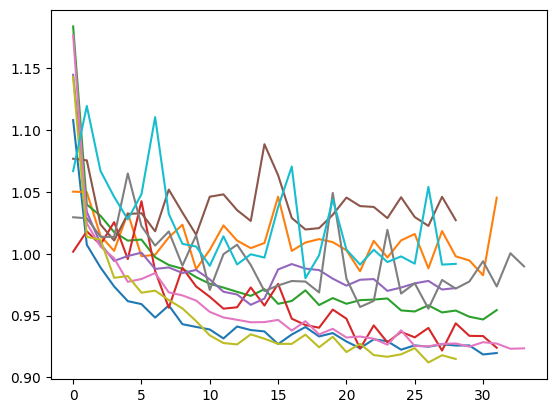

In [34]:
experiment = heartdesease

df_log = None
for SEED in SEEDS:
    torch.manual_seed(SEED);
    np.random.seed(SEED);
    
    ## Training data
    print(" \n On line Training \n ")
    trainingdata = TabularDataLoader( dataset_path = experiment.datasetpath+'_'+str(SEED), dataset_file = experiment.datasetfile+'_'+str(SEED),
                                     target_col = experiment.targetcol, header_in_data = True, 
                                     scale = True, batch_size = experiment.batchsize, validation_split = 0.2, 
                                     num_workers = 0)
    
    trainingdata_val = trainingdata.split_validation()
    
    
    gmoemodel = GMoE(input_size = experiment.inputfeatures, num_experts = experiment.num_experts, type_experts = experiment.type_experts, 
                     topk = experiment.topk, tau_init = experiment.tau_max ,tau_min = experiment.tau_min, gmoe_inference = experiment.gmoe_inference, dropout_rate = 0 )
    
    #gmoe_criterion = partial(BCELossLike_MoE, class_weights = experiment.class_weights)
    gmoe_criterion = MoELoss( lambda_l1_exp= experiment.lambda_l1_exp, lambda_l1_gate = experiment.lambda_l1_gate, class_weights = experiment.class_weights)
    
    experts_trainable_params = filter(lambda p: p.requires_grad, gmoemodel.experts.parameters())
    gate_trainable_params = filter(lambda p: p.requires_grad, gmoemodel.gate.parameters())
    #gmoe_optimizer = optim.Adam(filter(lambda p: p.requires_grad,gmoemodel.parameters()), lr = experiment.gmoe_learning_rate, weight_decay = experiment.gmoe_weightdecay, amsgrad=True)
    gmoe_optimizer = optim.Adam([{'params': experts_trainable_params}, {'params': gate_trainable_params, 'lr': experiment.gmoe_learning_rate_gate } ],
                                                                        lr = experiment.gmoe_learning_rate, weight_decay = experiment.gmoe_weightdecay, amsgrad=True)

    
    #gmoe_optimizer = optim.SGD([{'params': experts_trainable_params}, {'params': gate_trainable_params, 'lr': experiment.gmoe_learning_rate_gate } ],
    #                                                                    lr = experiment.gmoe_learning_rate, weight_decay = experiment.gmoe_weightdecay)
    #hi_optimizer = optim.SGD(himodel.parameters(), lr = experiment.hi_learning_rate, weight_decay = experiment.hi_weightdecay)
    #hi_optimizer = optim.SGD(himodel.parameters(), lr = experiment.hi_learning_rate, weight_decay = experiment.hi_weightdecay, momentum=0.9)
    g_scheduler = ExponentialLR(gmoe_optimizer, gamma = experiment.gamma_decay )
    #g_scheduler = CosineAnnealingLR(gmoe_optimizer, T_max = experiment.gmoe_num_epochs , eta_min = 0.0001 )
    
    ## Training First stage
    
    gmoe_list_loss_train = []
    gmoe_list_loss_val = []
    gmoe_list_loss_train, gmoe_list_loss_val = training_phase(experiment = experiment, gmoemodel = gmoemodel, gmoe_criterion = gmoe_criterion, 
                                                              gmoe_optimizer = gmoe_optimizer, 
                                                              g_scheduler = g_scheduler, trainingdata = trainingdata , 
                                                              trainingdata_val = trainingdata_val, gmoe_list_loss_train = gmoe_list_loss_train,
                                                              gmoe_list_loss_val = gmoe_list_loss_val, finetuning= False)
    
    ## Fine tuning GUMBEL
    
    print(" \n Fine Tuning \n ")
    gmoemodel.load_state_dict(torch.load('tmp/best_'+experiment.datasetfile+'.pth', weights_only = False));
    gmoemodel.freeze_experts()
    # experts_trainable_params = filter(lambda p: p.requires_grad, gmoemodel.experts.parameters())
    gate_trainable_params = filter(lambda p: p.requires_grad, gmoemodel.gate.parameters())
    gmoe_optimizer = optim.Adam( gate_trainable_params, lr = experiment.gmoe_learning_rate_ft, weight_decay = experiment.gmoe_weightdecay, amsgrad=True)
    g_scheduler = ExponentialLR(gmoe_optimizer, gamma = experiment.gamma_decay )
    
    gmoe_list_loss_train, gmoe_list_loss_val = training_phase(experiment = experiment, gmoemodel = gmoemodel, gmoe_criterion = gmoe_criterion, 
                                                              gmoe_optimizer = gmoe_optimizer, 
                                                              g_scheduler = g_scheduler, trainingdata = trainingdata , 
                                                              trainingdata_val = trainingdata_val, gmoe_list_loss_train = gmoe_list_loss_train,
                                                             gmoe_list_loss_val = gmoe_list_loss_val, finetuning = True)
    
    ## Training of GMoE first stage
    
    plt.plot(gmoe_list_loss_train);
    
    plt.plot(gmoe_list_loss_val);
    
    # Testing of the GMoE model
    
    ## Data for testing 
    
    testdata = TabularDataLoader( dataset_path = experiment.datasetpath+'_'+str(SEED), dataset_file = experiment.datasetfile+'_'+str(SEED),
                                 target_col = experiment.targetcol,
                                 header_in_data = True, scale = True, 
                                 batch_size = experiment.batchsize, validation_split = 0.0, 
                                 num_workers = 0, training = False )
    
    ## GNoE Metrics
    
    gmoemodel.load_state_dict(torch.load('tmp/best_'+experiment.datasetfile+'.pth', weights_only= False));
    gmoemodel.eval();
    
    df = testmodel(gmoemodel = gmoemodel, testdata = testdata, SEED = SEED)

    if df_log is not None:
        df_log = pd.concat([df_log, df], axis=0, join='outer', ignore_index=True)
    else: 
        df_log = df

# set the max columns to none
pd.set_option('display.max_columns', None)
df_log

In [35]:
results = logresults(df_log, tofile = False, file = 'moe2xp.xlsx' )
results

,Dataset,Batch size,Gate test,Gate,Gate FT,Experts Type,Number of Experts,Top K,LR - gate,LR - experts,LR - fine tuning,Scheduler decay,Accuracy,AUC ROC,AUC PRC,F1score,Precision,Sensitivity,Specificity,Fpr
0,heart_desease,16,soft,gsoft,gsoft,lin,2,0,0.03,0.03,0.03,1,0.851707,0.911942,0.895552,0.850619,0.831552,0.870854,0.832243,0.167757


In [32]:
testdata.dataset.x
MoEPrediction = namedtuple('MoEPrediction', ['moe_prediction', 'choosen_expert', 'gate_probs', 'experts_prediction'])

In [ ]:
gmoeprediction = gmoemodel.predict(torch.tensor(testdata.dataset.x))

In [ ]:
gmoeprediction.moe_prediction.detach().numpy()

In [ ]:
testdata.dataset.x

In [ ]:
df = pd.DataFrame(testdata.dataset.x, columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca' , 'thal'])

In [ ]:
df['MoE prediction'] = gmoeprediction.moe_prediction.detach().numpy()

In [ ]:
df['Label'] = testdata.dataset.y

In [ ]:
df['Choosen expert'] = gmoeprediction.choosen_expert.detach().numpy()

In [ ]:
df[['Gate Weight Exp_0', 'Gate Weight Exp_1']] = gmoeprediction.gate_probs.detach().numpy()

In [ ]:
df[['Prediction Exp_0', 'Prediction Exp_1']] = gmoeprediction.experts_prediction.squeeze().detach().numpy()

In [ ]:
my_new_index = ['MoE prediction', 'Label', 'Choosen expert', 'Gate Weight Exp_0', 'Gate Weight Exp_1', 'Prediction Exp_0', 'Prediction Exp_1', 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca' , 'thal' ]

In [ ]:
df_final = df[my_new_index]

In [ ]:
df_final.to_excel( 'log_test_heartdesease.xlsx' ,index=False)

In [ ]:
# from torchsummary import summary

In [ ]:
for name, param in gmoemodel.named_parameters():
        print(name, param.data)

## Heartdesease - Diabetes - Optuna

### Heartdesease

In [ ]:
import optuna

SEED = 42
torch.manual_seed(SEED);
np.random.seed(SEED);

experiment = heartdesease

In [ ]:
trainingdata = TabularDataLoader( dataset_path = experiment.datasetpath+'_'+str(SEED), dataset_file = experiment.datasetfile+'_'+str(SEED), 
                                     target_col = experiment.targetcol, header_in_data = True, 
                                     scale = True, batch_size = experiment.batchsize, validation_split = 0.2, 
                                     num_workers = 0)
    
trainingdata_val = trainingdata.split_validation()    

testdata = TabularDataLoader( dataset_path = experiment.datasetpath+'_'+str(SEED), dataset_file = experiment.datasetfile+'_'+str(SEED), 
                                 target_col = experiment.targetcol,
                                 header_in_data = True, scale = True, 
                                 batch_size = experiment.batchsize, validation_split = 0.0, 
                                 num_workers = 0, training = False )

In [ ]:
def objective(trial):
    lrate = trial.suggest_float('Learning Raste', 1e-5, 5e-1, log=True)
    #trial_num_experts = trial.suggest_categorical('Number of experts', [1,2,3,4,5,6,7,8,9,10])
    # trial_scheduler = trial.suggest_categorical('Scheduler Type', ['No_Sched', 'Exponential', 'Cosine'])
    
    trial_num_experts = 8
    trial_scheduler = 'No_Sced'
    

    # Training First stage
    gmoemodel = GMoE(input_size = experiment.inputfeatures, num_experts = trial_num_experts, type_experts = experiment.type_experts, 
                     topk = experiment.topk, tau_init = experiment.tau_max ,tau_min = experiment.tau_min, gmoe_inference = experiment.gmoe_inference)

    gmoe_criterion = partial(BCELossLike_MoE, class_weights = experiment.class_weights)

    gmoe_optimizer = optim.Adam(gmoemodel.parameters(), lr = lrate, weight_decay = experiment.gmoe_weightdecay, amsgrad=True)

    if trial_scheduler == 'No_Sced':
        g_scheduler = ExponentialLR(gmoe_optimizer, gamma = 1 )
    elif trial_scheduler == 'Exponential': 
        g_scheduler = ExponentialLR(gmoe_optimizer, gamma = 0.9 )
    else:
        g_scheduler = CosineAnnealingLR(gmoe_optimizer, T_max = experiment.gmoe_num_epochs , eta_min = 0.0000001 )

    _, _ = training_phase(experiment = experiment, gmoemodel = gmoemodel, gmoe_criterion = gmoe_criterion, 
                          gmoe_optimizer = gmoe_optimizer,
                                                              g_scheduler = g_scheduler, trainingdata = trainingdata , 
                                                              trainingdata_val = trainingdata_val, gmoe_list_loss_train = [],
                                                             gmoe_list_loss_val = [], finetuning= False, silent = True)

    ## Fine tuning GUMBEL
    
    gmoemodel.load_state_dict(torch.load('tmp/best_'+experiment.datasetfile+'.pth', weights_only= True));
    gmoemodel.freeze_experts()
    #experts_trainable_params = filter(lambda p: p.requires_grad, gmoemodel.experts.parameters())
    #gate_trainable_params = filter(lambda p: p.requires_grad, gmoemodel.gate.parameters())
    gmoe_optimizer = optim.Adam(gmoemodel.parameters(), lr = lrate, weight_decay = experiment.gmoe_weightdecay, amsgrad=True)

    if trial_scheduler == 'No_Sced':
        g_scheduler = ExponentialLR(gmoe_optimizer, gamma = 1 )
    elif trial_scheduler == 'Exponential': 
        g_scheduler = ExponentialLR(gmoe_optimizer, gamma = 0.9 )
    else:
        g_scheduler = CosineAnnealingLR(gmoe_optimizer, T_max = experiment.gmoe_num_epochs_ft , eta_min = 0.0000001 )
    
    _, _ = training_phase(experiment = experiment, gmoemodel = gmoemodel, gmoe_criterion = gmoe_criterion, 
                          gmoe_optimizer = gmoe_optimizer,
                                                              g_scheduler = g_scheduler, trainingdata = trainingdata , 
                                                              trainingdata_val = trainingdata_val, gmoe_list_loss_train = [],
                                                             gmoe_list_loss_val = [], finetuning = True, silent = True)

    ## GNoE Metrics
    
    gmoemodel.load_state_dict(torch.load('tmp/best_'+experiment.datasetfile+'.pth', weights_only= True));
    gmoemodel.eval();

    with torch.no_grad():
        df = testmodel(gmoemodel = gmoemodel, testdata = testdata, SEED = SEED)

    m = min(df['AUC ROC'].iloc[0], df['F1score'].iloc[0], df['Accuracy'].iloc[0])
    
    return m

In [ ]:
study = optuna.create_study(direction='maximize');
study.optimize(objective, n_trials=40);

print(f'Best trial score: {study.best_value}')
print(f'Best hyperparameters: {study.best_trial.params}')

# Sepsis 4 - BPIC2011

In [ ]:
datadir = './data/'

sepsis4 = ExperimentSetup(
    datasetpath = datadir + "sepsis_cases_4_full",
    datasetfile = "sepsis_cases_4",
    targetcol = "Classification",
    inputfeatures = 86,
    batchsize = 8,
    class_weights = [0.8,0.2],
    lambda_l1_exp = 0,
    lambda_l1_gate = 0, 
    num_experts = 2,
    type_experts = 'lin',
    type_fs = 'gsoft',
    gate = 'gsoft',
    gate_ft = 'gsoft',
    topk = 0,
    tau_max = 1,
    tau_min = 0.1,
    optimizer = 'Adam',
    gamma_decay = 1,
    early_stop = 10,
    gmoe_num_epochs = 100,
    gmoe_inference = 'soft',
    gmoe_learning_rate = 0.0001,
    gmoe_learning_rate_gate = 0.0001,
    gmoe_weightdecay = 0,
    gmoe_num_epochs_ft = 100,
    gmoe_learning_rate_ft = 0.0001,
    gmoe_weightdecay_ft = 0
)

sepsis4fs = ExperimentSetup(
    datasetpath = datadir + "sepsis_cases_4_full",
    datasetfile = "sepsis_cases_4",
    targetcol = "Classification",
    inputfeatures = 86,
    batchsize = 8,
    class_weights = [1,1],
    lambda_l1_exp = 0,
    lambda_l1_gate = 0, 
    num_experts = 2,
    type_experts = 'lin',
    type_fs = 'gsoft',
    gate = 'gsoft',
    gate_ft = 'gsoft',
    topk = 6,
    tau_max = 1,
    tau_min = 0.1,
    optimizer = 'Adam',
    gamma_decay = 1,
    early_stop = 10,
    gmoe_num_epochs = 100,
    gmoe_inference = 'soft',
    gmoe_learning_rate = 0.0006,
    gmoe_learning_rate_gate = 0.0006,
    gmoe_weightdecay = 0,
    gmoe_num_epochs_ft = 100,
    gmoe_learning_rate_ft = 0.0006,
    gmoe_weightdecay_ft = 0
)

bpic2011f4 = ExperimentSetup(
    datasetpath = datadir + "bpic2011_f4_full",
    datasetfile = "bpic2011_f4",
    targetcol = "Classification",
    inputfeatures = 326,
    batchsize = 8,
    class_weights = [1,1],
    lambda_l1_exp = 0,
    lambda_l1_gate = 0, 
    num_experts = 6,
    type_experts = 'lin',
    type_fs = 'gsoft',
    gate = 'gsoft',
    gate_ft = 'gsoft',
    topk = 0,
    tau_max = 1,
    tau_min = 0.1,
    optimizer = 'Adam',
    gamma_decay = 1,
    early_stop = 10,
    gmoe_num_epochs = 100,
    gmoe_inference = 'soft',
    gmoe_learning_rate = 0.0001,
    gmoe_learning_rate_gate = 0.0001,
    gmoe_weightdecay = 0,
    gmoe_num_epochs_ft = 100,
    gmoe_learning_rate_ft = 0.0001,
    gmoe_weightdecay_ft = 0
)

bpic2011f4fs = ExperimentSetup(
    datasetpath = datadir + "bpic2011_f4_full",
    datasetfile = "bpic2011_f4",
    targetcol = "Classification",
    inputfeatures = 326,
    batchsize = 8,
    class_weights = [1,1],
    lambda_l1_exp = 0,
    lambda_l1_gate = 0, 
    num_experts = 6,
    type_experts = 'lin',
    type_fs = 'gsoft',
    gate = 'gsoft',
    gate_ft = 'gsoft',
    topk = 6,
    tau_max = 1,
    tau_min = 0.1,
    optimizer = 'Adam',
    gamma_decay = 1,
    early_stop = 10,
    gmoe_num_epochs = 100,
    gmoe_inference = 'soft',
    gmoe_learning_rate = 0.0008,
    gmoe_learning_rate_gate = 0.0008,
    gmoe_weightdecay = 0,
    gmoe_num_epochs_ft = 100,
    gmoe_learning_rate_ft = 0.0008,
    gmoe_weightdecay_ft = 0
)

In [ ]:
experiment = bpic2011f4fs

df_log = None
for SEED in SEEDS:
    torch.manual_seed(SEED);
    np.random.seed(SEED);
    
    ## Training data
    print(" \n On line Training \n ")
    trainingdata = TabularDataLoader( dataset_path = experiment.datasetpath, dataset_file = experiment.datasetfile, 
                                     target_col = experiment.targetcol, header_in_data = True, 
                                     scale = True, batch_size = experiment.batchsize, validation_split = 0.2, 
                                     num_workers = 0)
    
    trainingdata_val = trainingdata.split_validation()
    
    
    gmoemodel = GMoE(input_size = experiment.inputfeatures, num_experts = experiment.num_experts, type_experts = experiment.type_experts, 
                     topk = experiment.topk, tau_init = experiment.tau_max ,tau_min = experiment.tau_min, gmoe_inference = experiment.gmoe_inference, dropout_rate = 0 )
    
    #gmoe_criterion = partial(BCELossLike_MoE, class_weights = experiment.class_weights)
    gmoe_criterion = MoELoss( lambda_l1_exp= experiment.lambda_l1_exp, lambda_l1_gate = experiment.lambda_l1_gate, class_weights = experiment.class_weights)
    
    experts_trainable_params = filter(lambda p: p.requires_grad, gmoemodel.experts.parameters())
    gate_trainable_params = filter(lambda p: p.requires_grad, gmoemodel.gate.parameters())
    #gmoe_optimizer = optim.Adam(filter(lambda p: p.requires_grad,gmoemodel.parameters()), lr = experiment.gmoe_learning_rate, weight_decay = experiment.gmoe_weightdecay, amsgrad=True)
    gmoe_optimizer = optim.Adam([{'params': experts_trainable_params}, {'params': gate_trainable_params, 'lr': experiment.gmoe_learning_rate_gate } ],
                                                                        lr = experiment.gmoe_learning_rate, weight_decay = experiment.gmoe_weightdecay, amsgrad=True)

    
    #gmoe_optimizer = optim.SGD([{'params': experts_trainable_params}, {'params': gate_trainable_params, 'lr': experiment.gmoe_learning_rate_gate } ],
    #                                                                    lr = experiment.gmoe_learning_rate, weight_decay = experiment.gmoe_weightdecay)
    #hi_optimizer = optim.SGD(himodel.parameters(), lr = experiment.hi_learning_rate, weight_decay = experiment.hi_weightdecay)
    #hi_optimizer = optim.SGD(himodel.parameters(), lr = experiment.hi_learning_rate, weight_decay = experiment.hi_weightdecay, momentum=0.9)
    g_scheduler = ExponentialLR(gmoe_optimizer, gamma = experiment.gamma_decay )
    #g_scheduler = CosineAnnealingLR(gmoe_optimizer, T_max = experiment.gmoe_num_epochs , eta_min = 0.0001 )
    
    ## Training First stage
    
    gmoe_list_loss_train = []
    gmoe_list_loss_val = []
    gmoe_list_loss_train, gmoe_list_loss_val = training_phase(experiment = experiment, gmoemodel = gmoemodel, gmoe_criterion = gmoe_criterion, 
                                                              gmoe_optimizer = gmoe_optimizer, 
                                                              g_scheduler = g_scheduler, trainingdata = trainingdata , 
                                                              trainingdata_val = trainingdata_val, gmoe_list_loss_train = gmoe_list_loss_train,
                                                              gmoe_list_loss_val = gmoe_list_loss_val, finetuning= False)
    
    ## Fine tuning GUMBEL
    
    print(" \n Fine Tuning \n ")
    gmoemodel.load_state_dict(torch.load('tmp/best_'+experiment.datasetfile+'.pth', weights_only = False));
    gmoemodel.freeze_experts()
    # experts_trainable_params = filter(lambda p: p.requires_grad, gmoemodel.experts.parameters())
    gate_trainable_params = filter(lambda p: p.requires_grad, gmoemodel.gate.parameters())
    gmoe_optimizer = optim.Adam( gate_trainable_params, lr = experiment.gmoe_learning_rate_ft, weight_decay = experiment.gmoe_weightdecay, amsgrad=True)
    g_scheduler = ExponentialLR(gmoe_optimizer, gamma = experiment.gamma_decay )
    
    gmoe_list_loss_train, gmoe_list_loss_val = training_phase(experiment = experiment, gmoemodel = gmoemodel, gmoe_criterion = gmoe_criterion, 
                                                              gmoe_optimizer = gmoe_optimizer, 
                                                              g_scheduler = g_scheduler, trainingdata = trainingdata , 
                                                              trainingdata_val = trainingdata_val, gmoe_list_loss_train = gmoe_list_loss_train,
                                                             gmoe_list_loss_val = gmoe_list_loss_val, finetuning = True)
    
    ## Training of GMoE first stage
    
    plt.plot(gmoe_list_loss_train);
    
    plt.plot(gmoe_list_loss_val);
    
    # Testing of the GMoE model
    
    ## Data for testing 
    
    testdata = TabularDataLoader( dataset_path = experiment.datasetpath, dataset_file = experiment.datasetfile, 
                                 target_col = experiment.targetcol,
                                 header_in_data = True, scale = True, 
                                 batch_size = experiment.batchsize, validation_split = 0.0, 
                                 num_workers = 0, training = False )
    
    ## GNoE Metrics
    
    gmoemodel.load_state_dict(torch.load('tmp/best_'+experiment.datasetfile+'.pth', weights_only= False));
    gmoemodel.eval();
    
    df = testmodel(gmoemodel = gmoemodel, testdata = testdata, SEED = SEED)

    if df_log is not None:
        df_log = pd.concat([df_log, df], axis=0, join='outer', ignore_index=True)
    else: 
        df_log = df

# set the max columns to none
pd.set_option('display.max_columns', None)
df_log

In [ ]:
results = logresults(df_log, tofile = True, file='moe2xp.xlsx')
results

## Optuna Bpic2011 f4

In [ ]:
import optuna

SEED = 42
torch.manual_seed(SEED);
np.random.seed(SEED);

experiment = bpic2011f4fs

In [ ]:
trainingdata = TabularDataLoader( dataset_path = experiment.datasetpath, dataset_file = experiment.datasetfile, 
                                     target_col = experiment.targetcol, header_in_data = True, 
                                     scale = True, batch_size = experiment.batchsize, validation_split = 0.2, 
                                     num_workers = 0)
    
trainingdata_val = trainingdata.split_validation()    

testdata = TabularDataLoader( dataset_path = experiment.datasetpath, dataset_file = experiment.datasetfile, 
                                 target_col = experiment.targetcol,
                                 header_in_data = True, scale = True, 
                                 batch_size = experiment.batchsize, validation_split = 0.0, 
                                 num_workers = 0, training = False )

In [ ]:
def objective(trial):
    lrate = trial.suggest_float('Learning Rate', 1e-6, 1e-1, log=True)
    #trial_num_experts = trial.suggest_categorical('Number of experts', [1,2,3,4,5,6,7,8,9,10])
    # trial_scheduler = trial.suggest_categorical('Scheduler Type', ['No_Sched', 'Exponential', 'Cosine'])
    
    trial_num_experts = 6
    trial_scheduler = 'No_Sced'
    

    # Training First stage
    gmoemodel = GMoE(input_size = experiment.inputfeatures, num_experts = trial_num_experts, type_experts = experiment.type_experts, 
                     topk = experiment.topk, tau_init = experiment.tau_max ,tau_min = experiment.tau_min, gmoe_inference = experiment.gmoe_inference)

    gmoe_criterion = partial(BCELossLike_MoE, class_weights = experiment.class_weights)

    gmoe_optimizer = optim.Adam(gmoemodel.parameters(), lr = lrate, weight_decay = experiment.gmoe_weightdecay, amsgrad=True)

    if trial_scheduler == 'No_Sced':
        g_scheduler = ExponentialLR(gmoe_optimizer, gamma = 1 )
    elif trial_scheduler == 'Exponential': 
        g_scheduler = ExponentialLR(gmoe_optimizer, gamma = 0.9 )
    else:
        g_scheduler = CosineAnnealingLR(gmoe_optimizer, T_max = experiment.gmoe_num_epochs , eta_min = 0.0000001 )

    _, _ = training_phase(experiment = experiment, gmoemodel = gmoemodel, gmoe_criterion = gmoe_criterion, 
                          gmoe_optimizer = gmoe_optimizer,
                                                              g_scheduler = g_scheduler, trainingdata = trainingdata , 
                                                              trainingdata_val = trainingdata_val, gmoe_list_loss_train = [],
                                                             gmoe_list_loss_val = [], finetuning= False, silent = True)

    ## Fine tuning GUMBEL
    
    gmoemodel.load_state_dict(torch.load('tmp/best_'+experiment.datasetfile+'.pth', weights_only= True));
    gmoemodel.freeze_experts()
    #experts_trainable_params = filter(lambda p: p.requires_grad, gmoemodel.experts.parameters())
    #gate_trainable_params = filter(lambda p: p.requires_grad, gmoemodel.gate.parameters())
    gmoe_optimizer = optim.Adam(gmoemodel.parameters(), lr = lrate, weight_decay = experiment.gmoe_weightdecay, amsgrad=True)

    if trial_scheduler == 'No_Sced':
        g_scheduler = ExponentialLR(gmoe_optimizer, gamma = 1 )
    elif trial_scheduler == 'Exponential': 
        g_scheduler = ExponentialLR(gmoe_optimizer, gamma = 0.9 )
    else:
        g_scheduler = CosineAnnealingLR(gmoe_optimizer, T_max = experiment.gmoe_num_epochs_ft , eta_min = 0.0000001 )
    
    _, _ = training_phase(experiment = experiment, gmoemodel = gmoemodel, gmoe_criterion = gmoe_criterion, 
                          gmoe_optimizer = gmoe_optimizer,
                                                              g_scheduler = g_scheduler, trainingdata = trainingdata , 
                                                              trainingdata_val = trainingdata_val, gmoe_list_loss_train = [],
                                                             gmoe_list_loss_val = [], finetuning = True, silent = True)

    ## GNoE Metrics
    
    gmoemodel.load_state_dict(torch.load('tmp/best_'+experiment.datasetfile+'.pth', weights_only= True));
    gmoemodel.eval();

    with torch.no_grad():
        df = testmodel(gmoemodel = gmoemodel, testdata = testdata, SEED = SEED)

    m = min(df['AUC ROC'].iloc[0], df['F1score'].iloc[0], df['Accuracy'].iloc[0])
    
    return m

In [ ]:
study = optuna.create_study(direction='maximize');
study.optimize(objective, n_trials=80);

print(f'Best trial score: {study.best_value}')
print(f'Best hyperparameters: {study.best_trial.params}')

In [ ]:
[i for i in range(4)]